# 🌿 Kapeng Barako — MobileNetV2 Model Manual Testing
Manual evaluation of leaf, bark, and cherry models on custom images.

**Models expected:**
- `models/leaf_MobileNetV2_80-20_model.keras`
- `models/bark_MobileNetV2_80-20_model.keras`
- `models/cherry_MobileNetV2_80-20_model.keras`

## 1. Install & Import Dependencies

In [ ]:
# Install if not already installed
# !pip install tensorflow keras pillow opencv-python matplotlib seaborn scikit-learn

In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
import keras
from keras.models import Model
from PIL import Image
import io
import base64

print(f'TensorFlow version : {tf.__version__}')
print(f'Keras version      : {keras.__version__}')
print(f'GPU available      : {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version : 2.21.0
Keras version      : 3.13.2
GPU available      : False


## 2. Configuration — Set your paths here

In [2]:
# ── Model paths ──────────────────────────────────────────────────────────────
MODEL_DIR = '.'   # same folder as the notebook

MODEL_PATHS = {
    'leaf'  : r'C:\Users\vikoimontano\Desktop\ModelTesting\leaf_MobileNetV2_80-20_model.keras',
    'bark'  : r'C:\Users\vikoimontano\Desktop\ModelTesting\bark_MobileNetV2_80-20_model.keras',
    'cherry': r'C:\Users\vikoimontano\Desktop\ModelTesting\cherry_MobileNetV2_80-20_model.keras',
}

# ── Classification threshold ─────────────────────────────────────────────────
# Increase if model over-predicts Liberica (e.g. try 0.60, 0.65, 0.70)
THRESHOLD = 0.50

# ── Image input size (must match training) ───────────────────────────────────
IMG_SIZE = (224, 224)

# ── Test image folder (optional batch testing) ───────────────────────────────
# Put test images in subfolders: test_images/liberica/ and test_images/not_liberica/
TEST_IMAGE_DIR = 'test_images'

print('Configuration loaded ✓')
for organ, path in MODEL_PATHS.items():
    exists = os.path.exists(path)
    status = '✓ found' if exists else '✗ NOT FOUND'
    print(f'  {organ:8s} model: {status} — {path}')

Configuration loaded ✓
  leaf     model: ✓ found — C:\Users\vikoimontano\Desktop\ModelTesting\leaf_MobileNetV2_80-20_model.keras
  bark     model: ✓ found — C:\Users\vikoimontano\Desktop\ModelTesting\bark_MobileNetV2_80-20_model.keras
  cherry   model: ✓ found — C:\Users\vikoimontano\Desktop\ModelTesting\cherry_MobileNetV2_80-20_model.keras


## 3. Load Models

In [3]:
MODELS = {}

for organ, path in MODEL_PATHS.items():
    if os.path.exists(path):
        print(f'Loading {organ} model...', end=' ')
        MODELS[organ] = keras.models.load_model(path)
        print('done ✓')
    else:
        print(f'⚠ Skipping {organ} — file not found: {path}')

print(f'\nLoaded {len(MODELS)} model(s): {list(MODELS.keys())}')

Loading leaf model... done ✓
Loading bark model... done ✓
Loading cherry model... done ✓

Loaded 3 model(s): ['leaf', 'bark', 'cherry']


## 4. Preprocessing & Helper Functions

In [4]:
def preprocess_image(image_input):
    """
    Accept a file path, PIL Image, or bytes.
    Returns (preprocessed_array, original_pil_image)
    """
    if isinstance(image_input, str):
        img = Image.open(image_input).convert('RGB')
    elif isinstance(image_input, bytes):
        img = Image.open(io.BytesIO(image_input)).convert('RGB')
    elif isinstance(image_input, Image.Image):
        img = image_input.convert('RGB')
    else:
        raise ValueError('image_input must be a file path, bytes, or PIL Image')

    original = img.copy()
    resized  = img.resize(IMG_SIZE)
    arr      = np.array(resized, dtype=np.float32) / 255.0
    arr      = np.expand_dims(arr, axis=0)          # shape: (1, 224, 224, 3)
    return arr, original


def make_gradcam_heatmap(img_array, model):
    """Generate Grad-CAM heatmap — matches production code."""
    layer_names = ['out_relu', 'Conv_1', 'block_16_project', 'block_16_expand']
    last_conv_layer = None

    for name in layer_names:
        try:
            last_conv_layer = model.get_layer(name)
            print(f'  Grad-CAM using layer: {name}')
            break
        except:
            continue

    if last_conv_layer is None:
        return None

    grad_model = Model(
        inputs=[model.inputs],
        outputs=[last_conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array)
        if isinstance(preds, list): preds = preds[0]
        class_channel = preds[:, 0]

    grads = tape.gradient(class_channel, conv_out)
    if grads is None:
        return None

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out_np  = conv_out.numpy()
    if len(conv_out_np.shape) == 4:
        conv_out_np = conv_out_np[0]

    for i in range(pooled_grads.numpy().shape[0]):
        conv_out_np[:, :, i] *= pooled_grads.numpy()[i]

    heatmap = np.mean(conv_out_np, axis=-1)
    heatmap = np.maximum(heatmap, 0)
    if heatmap.max() > 0:
        heatmap /= heatmap.max()
    return heatmap


def overlay_gradcam(pil_img, heatmap, alpha=0.4):
    """Superimpose Grad-CAM heatmap on original image."""
    h = cv2.resize(heatmap, (pil_img.width, pil_img.height))
    colored = cv2.applyColorMap(np.uint8(255 * h), cv2.COLORMAP_JET)
    colored = cv2.cvtColor(colored, cv2.COLOR_BGR2RGB)
    blended = colored * alpha + np.array(pil_img) * (1 - alpha)
    return np.clip(blended, 0, 255).astype(np.uint8)


print('Helper functions defined ✓')

Helper functions defined ✓


## 5. Predict a Single Image

In [5]:
def predict_single(image_input, plant_part='mix', show_gradcam=True, threshold=THRESHOLD):
    """
    Predict a single image.

    Parameters
    ----------
    image_input : str | PIL.Image | bytes
    plant_part  : 'mix' | 'leaf' | 'bark' | 'cherry'
    show_gradcam: bool — show Grad-CAM overlay
    threshold   : float — confidence threshold for Liberica (default 0.50)
    """
    arr, original = preprocess_image(image_input)

    models_to_use = MODELS if plant_part == 'mix' else {plant_part: MODELS[plant_part]}

    liberica_votes    = 0
    not_lib_votes     = 0
    max_confidence    = 0
    winning_model     = None
    winning_organ     = None
    individual        = {}

    for organ, model in models_to_use.items():
        pred          = model.predict(arr, verbose=0)
        lib_prob      = float(pred[0][0])
        not_lib_prob  = 1 - lib_prob
        label         = 'Not Liberica' if lib_prob >= threshold else 'Liberica' #eto yung binago
        conf          = max(lib_prob, not_lib_prob)

        individual[organ] = {
            'prediction' : label,
            'liberica_prob': round(lib_prob * 100, 2),
            'confidence' : round(conf * 100, 2),
        }

        if label == 'Liberica':
            liberica_votes += 1
        else:
            not_lib_votes += 1

        if conf > max_confidence:
            max_confidence = conf
            winning_model  = model
            winning_organ  = organ

    # Final decision
    if plant_part == 'mix':
        final = 'Liberica' if liberica_votes >= 2 else 'Not Liberica'
        total = liberica_votes + not_lib_votes
        conf_ratio = round(max(liberica_votes, not_lib_votes) / total * 100, 2)
    else:
        final      = individual[plant_part]['prediction']
        conf_ratio = individual[plant_part]['confidence']

    # ── Plot ─────────────────────────────────────────────────────────────────
    n_cols = 2 + (len(models_to_use) if show_gradcam else 0)
    fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 5))
    if n_cols == 1:
        axes = [axes]

    # Original image
    axes[0].imshow(original)
    axes[0].set_title('Input Image', fontsize=12)
    axes[0].axis('off')

    # Prediction summary bar chart
    organs  = list(individual.keys())
    lib_probs = [individual[o]['liberica_prob'] for o in organs]
    colors  = ['#1D9E75' if individual[o]['prediction'] == 'Liberica' else '#E24B4A'
               for o in organs]

    ax = axes[1]
    bars = ax.barh(organs, lib_probs, color=colors, height=0.5)
    ax.axvline(threshold * 100, color='#888', linestyle='--', linewidth=1.5,
               label=f'Threshold ({threshold*100:.0f}%)')
    ax.set_xlim(0, 100)
    ax.set_xlabel('Liberica probability (%)')
    ax.set_title('Per-model confidence')
    ax.legend(fontsize=9)
    for bar, prob in zip(bars, lib_probs):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                f'{prob:.1f}%', va='center', fontsize=10)

    # Grad-CAM overlays
    if show_gradcam:
        for i, (organ, model) in enumerate(models_to_use.items()):
            heatmap = make_gradcam_heatmap(arr, model)
            ax_gc = axes[2 + i]
            if heatmap is not None:
                overlay = overlay_gradcam(original, heatmap)
                ax_gc.imshow(overlay)
            else:
                ax_gc.imshow(original)
            ax_gc.set_title(f'Grad-CAM ({organ})', fontsize=12)
            ax_gc.axis('off')

    # Overall result header
    color = '#1D9E75' if final == 'Liberica' else '#E24B4A'
    fig.suptitle(
        f'Result: {final}  |  Confidence: {conf_ratio:.1f}%  |  Mode: {plant_part}',
        fontsize=14, fontweight='bold', color=color, y=1.02
    )
    plt.tight_layout()
    plt.show()

    # ── Print summary ────────────────────────────────────────────────────────
    print('=' * 55)
    print(f'  FINAL PREDICTION : {final}')
    print(f'  CONFIDENCE RATIO : {conf_ratio:.1f}%')
    print(f'  MODE             : {plant_part}')
    print(f'  THRESHOLD        : {threshold * 100:.0f}%')
    print('-' * 55)
    for organ, res in individual.items():
        flag = '✓' if res['prediction'] == 'Liberica' else '✗'
        print(f'  {flag} {organ:8s}: {res["prediction"]:14s}  '
              f'lib_prob={res["liberica_prob"]:5.1f}%  '
              f'conf={res["confidence"]:5.1f}%')
    print('=' * 55)

    return {
        'final_prediction'      : final,
        'confidence_ratio'      : conf_ratio,
        'plant_part_mode'       : plant_part,
        'individual_predictions': individual,
    }


print('predict_single() ready ✓')

predict_single() ready ✓


## 6. Run a Test — Single Image
Change `IMAGE_PATH` and `PLANT_PART` below.

  Grad-CAM using layer: out_relu


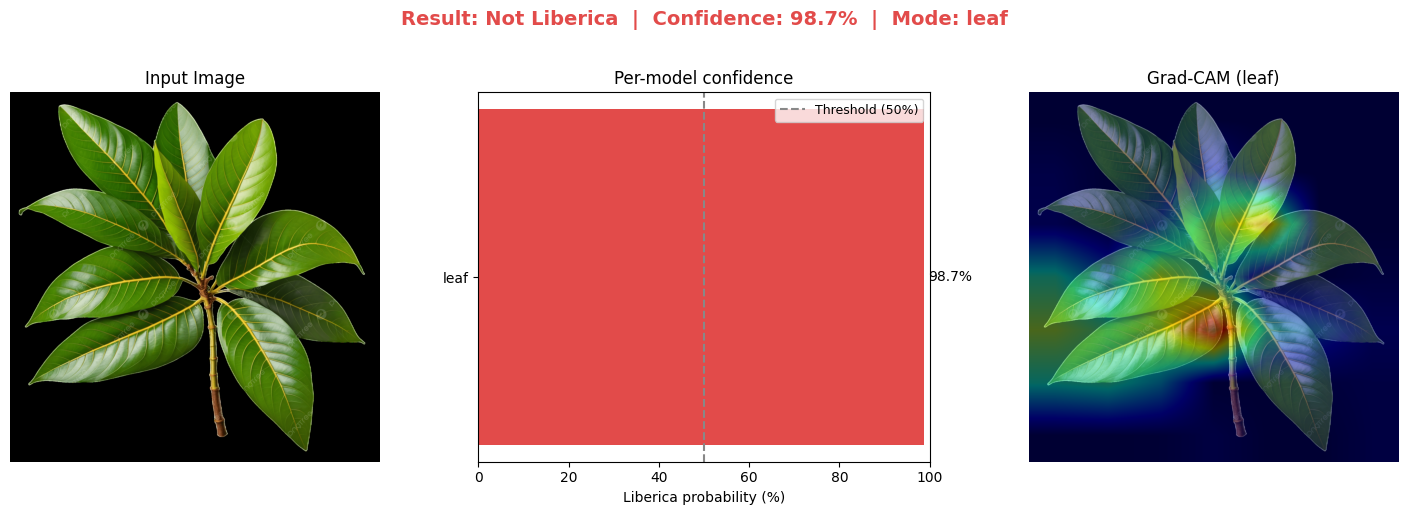

  FINAL PREDICTION : Not Liberica
  CONFIDENCE RATIO : 98.7%
  MODE             : leaf
  THRESHOLD        : 50%
-------------------------------------------------------
  ✗ leaf    : Not Liberica    lib_prob= 98.7%  conf= 98.7%


In [12]:
# ── Edit these ───────────────────────────────────────────────────────────────
IMAGE_PATH = r'C:\Users\vikoimontano\Downloads\pngtree-mango-leaf-isolated-on-transparent-background-png-image_15616448-Photoroom.png'  # path to your test image
PLANT_PART = 'leaf'                            # 'mix' | 'leaf' | 'bark' | 'cherry'
THRESHOLD  = 0.50                             # try 0.60 or 0.65 if over-predicting
# ─────────────────────────────────────────────────────────────────────────────

result = predict_single(
    IMAGE_PATH,
    plant_part=PLANT_PART,
    show_gradcam=True,
    threshold=THRESHOLD
)

## 7. Batch Test — Multiple Images
Put images in `test_images/liberica/` and `test_images/not_liberica/` folders.

In [ ]:
def batch_test(image_dir, plant_part='mix', threshold=THRESHOLD, extensions=('jpg','jpeg','png')):
    """
    Batch test all images in image_dir.
    Expects subfolders: liberica/ and not_liberica/
    Returns accuracy, confusion matrix, and per-image results.
    """
    results   = []
    tp = fp = tn = fn = 0

    for true_label in ['liberica', 'not_liberica']:
        folder = os.path.join(image_dir, true_label)
        if not os.path.exists(folder):
            print(f'  ⚠ Folder not found: {folder} — skipping')
            continue

        files = []
        for ext in extensions:
            files += glob.glob(os.path.join(folder, f'*.{ext}'))
            files += glob.glob(os.path.join(folder, f'*.{ext.upper()}'))

        print(f'\nTesting {len(files)} images from {true_label}/')

        for path in files:
            try:
                arr, _ = preprocess_image(path)
                models_to_use = MODELS if plant_part == 'mix' else {plant_part: MODELS[plant_part]}
                lib_votes = 0
                tot_votes = 0

                for organ, model in models_to_use.items():
                    pred     = model.predict(arr, verbose=0)
                    lib_prob = float(pred[0][0])
                    if lib_prob >= threshold:
                        lib_votes += 1
                    tot_votes += 1

                if plant_part == 'mix':
                    predicted = 'Liberica' if lib_votes >= 2 else 'Not Liberica'
                else:
                    predicted = 'Liberica' if lib_votes > 0 else 'Not Liberica'

                actual = 'Liberica' if true_label == 'liberica' else 'Not Liberica'
                correct = predicted == actual

                if actual == 'Liberica' and predicted == 'Liberica':   tp += 1
                elif actual == 'Liberica' and predicted != 'Liberica': fn += 1
                elif actual != 'Liberica' and predicted == 'Liberica': fp += 1
                else:                                                   tn += 1

                results.append({
                    'file'     : os.path.basename(path),
                    'actual'   : actual,
                    'predicted': predicted,
                    'correct'  : correct,
                })
                icon = '✓' if correct else '✗'
                print(f'  {icon} {os.path.basename(path):30s}  actual={actual:14s}  pred={predicted}')

            except Exception as e:
                print(f'  ✗ Error on {path}: {e}')

    total    = tp + tn + fp + fn
    accuracy = (tp + tn) / total * 100 if total > 0 else 0
    precision = tp / (tp + fp) * 100 if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) * 100 if (tp + fn) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    # ── Confusion matrix plot ────────────────────────────────────────────────
    cm = np.array([[tp, fn], [fp, tn]])
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Pred: Liberica', 'Pred: Not Lib'],
                yticklabels=['Act: Liberica',  'Act: Not Lib'],
                ax=axes[0])
    axes[0].set_title('Confusion Matrix')

    metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
    values  = [accuracy, precision, recall, f1]
    colors  = ['#1D9E75' if v >= 70 else '#E24B4A' for v in values]
    axes[1].barh(metrics, values, color=colors, height=0.5)
    axes[1].set_xlim(0, 100)
    axes[1].set_xlabel('Score (%)')
    axes[1].set_title('Performance Metrics')
    for i, v in enumerate(values):
        axes[1].text(v + 1, i, f'{v:.1f}%', va='center')

    plt.suptitle(f'Batch Test Results — {plant_part} mode | threshold={threshold*100:.0f}%',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print('\n' + '=' * 55)
    print(f'  Total images : {total}')
    print(f'  Accuracy     : {accuracy:.1f}%')
    print(f'  Precision    : {precision:.1f}%')
    print(f'  Recall       : {recall:.1f}%')
    print(f'  F1 Score     : {f1:.1f}%')
    print(f'  TP={tp}  TN={tn}  FP={fp}  FN={fn}')
    print('=' * 55)

    return results, {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}


print('batch_test() ready ✓')

In [ ]:
# ── Edit these ───────────────────────────────────────────────────────────────
BATCH_DIR  = 'test_images'   # must have liberica/ and not_liberica/ subfolders
PLANT_PART = 'mix'
THRESHOLD  = 0.50
# ─────────────────────────────────────────────────────────────────────────────

batch_results, metrics = batch_test(BATCH_DIR, plant_part=PLANT_PART, threshold=THRESHOLD)

## 8. Threshold Sensitivity Analysis
Find the best threshold for your dataset.

In [ ]:
def threshold_analysis(image_dir, plant_part='mix', thresholds=None):
    """
    Test multiple thresholds and plot accuracy vs threshold.
    """
    if thresholds is None:
        thresholds = [0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]

    # Pre-collect all raw probabilities once
    all_data = []  # list of (lib_probs_dict, actual_label)

    for true_label in ['liberica', 'not_liberica']:
        folder = os.path.join(image_dir, true_label)
        if not os.path.exists(folder):
            continue
        files = []
        for ext in ('jpg', 'jpeg', 'png', 'JPG', 'JPEG', 'PNG'):
            files += glob.glob(os.path.join(folder, f'*.{ext}'))
        for path in files:
            try:
                arr, _ = preprocess_image(path)
                probs = {}
                models_to_use = MODELS if plant_part == 'mix' else {plant_part: MODELS[plant_part]}
                for organ, model in models_to_use.items():
                    pred = model.predict(arr, verbose=0)
                    probs[organ] = float(pred[0][0])
                actual = 'Liberica' if true_label == 'liberica' else 'Not Liberica'
                all_data.append((probs, actual))
            except:
                pass

    if not all_data:
        print('No images found — check your test_images folder structure.')
        return

    accs = []
    for t in thresholds:
        correct = 0
        for probs, actual in all_data:
            models_to_use = MODELS if plant_part == 'mix' else {plant_part: MODELS[plant_part]}
            lib_votes = sum(1 for p in probs.values() if p >= t)
            if plant_part == 'mix':
                predicted = 'Liberica' if lib_votes >= 2 else 'Not Liberica'
            else:
                predicted = 'Liberica' if lib_votes > 0 else 'Not Liberica'
            if predicted == actual:
                correct += 1
        accs.append(correct / len(all_data) * 100)

    best_idx = int(np.argmax(accs))
    best_t   = thresholds[best_idx]
    best_acc = accs[best_idx]

    plt.figure(figsize=(9, 4))
    plt.plot([t*100 for t in thresholds], accs,
             marker='o', color='#1D9E75', linewidth=2, markersize=7)
    plt.axvline(best_t * 100, color='#E24B4A', linestyle='--',
                label=f'Best: {best_t*100:.0f}% → acc={best_acc:.1f}%')
    plt.xlabel('Threshold (%)')
    plt.ylabel('Accuracy (%)')
    plt.title(f'Threshold Sensitivity — {plant_part} mode ({len(all_data)} images)')
    plt.legend()
    plt.ylim(0, 105)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f'\nBest threshold : {best_t*100:.0f}%')
    print(f'Best accuracy  : {best_acc:.1f}%')
    for t, a in zip(thresholds, accs):
        marker = ' ← best' if t == best_t else ''
        print(f'  threshold={t*100:.0f}%  accuracy={a:.1f}%{marker}')

    return best_t, best_acc


print('threshold_analysis() ready ✓')

In [ ]:
# Run threshold analysis
best_threshold, best_accuracy = threshold_analysis('test_images', plant_part='mix')

## 9. Model Architecture Summary

In [ ]:
for organ, model in MODELS.items():
    print(f'\n{'='*50}')
    print(f'  MODEL: {organ.upper()}')
    print(f'{'='*50}')
    print(f'  Input shape  : {model.input_shape}')
    print(f'  Output shape : {model.output_shape}')
    print(f'  Total params : {model.count_params():,}')
    print(f'  Layers       : {len(model.layers)}')
    print(f'  Last layer   : {model.layers[-1].name} ({model.layers[-1].__class__.__name__})')
    
    # Show available conv layers for Grad-CAM
    conv_layers = [l.name for l in model.layers
                   if any(n in l.name for n in ['out_relu','Conv_1','block_16'])]
    print(f'  Grad-CAM candidates: {conv_layers}')